# 03 — Estimation (multi-arm) for Experiments

This notebook demonstrates how to estimate treatment effects in a multi-arm experiment using `causalx`.

We'll cover:
1. Creating a simple synthetic dataset with covariates
2. Assigning users to multiple arms (Control / A / B)
3. Checking covariate balance (optional but recommended)
4. Estimating effects for:
   - a **continuous** outcome (difference in means)
   - a **binary** outcome (difference in proportions)

**Key idea:** In v0.1, `causalx` returns structured results (estimate, standard error, CI) and supports multi-arm contrasts vs a reference arm (typically control).


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from causalx.analysis.estimators import diff_in_means
from causalx.assignment import assign_treatment, smd


## 1) Create a synthetic dataset

We simulate:
- covariates: `age`, `prior_spend`, `is_mobile`, `region`
- a multi-arm assignment (control / variant_a / variant_b)
- outcomes:
  - `revenue` (continuous)
  - `converted` (binary)

This is for demonstration only—the workflow mirrors what you'd do on real experiment data.


In [2]:
rng = np.random.default_rng(0)
n = 8000

df = pd.DataFrame({
    "user_id": np.arange(n),
    "age": rng.normal(35, 10, size=n).clip(18, 80),
    "prior_spend": rng.lognormal(mean=3.2, sigma=0.6, size=n),
    "is_mobile": (rng.random(n) < 0.55).astype(int),
    "region": rng.choice(["NE", "MW", "S", "W"], size=n, p=[0.2, 0.25, 0.35, 0.2]),
})

df.head()


,user_id,age,prior_spend,is_mobile,region
0,0,36.257302,34.824057,1,S
1,1,33.678951,10.616213,1,NE
2,2,41.404227,24.013246,1,S
3,3,36.049001,5.056398,1,S
4,4,29.643306,39.323680,0,S


## 2) Assign users to multiple arms

We assign:
- 50% control
- 25% variant_a
- 25% variant_b

We use a `seed` so the assignment is reproducible.


In [3]:
df_assigned = assign_treatment(
    df,
    arms=("control", "variant_a", "variant_b"),
    probs=(0.50, 0.25, 0.25),
    seed=42,
    treatment_col="arm",
)

df_assigned["arm"].value_counts(normalize=True)


arm
control      0.505375
variant_a    0.249625
variant_b    0.245000
Name: proportion, dtype: float64

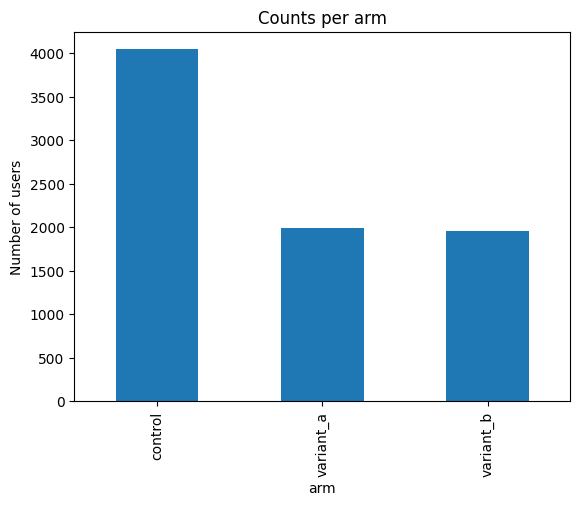

In [4]:
plt.figure()
df_assigned["arm"].value_counts().plot(kind="bar")
plt.title("Counts per arm")
plt.ylabel("Number of users")
plt.show()


## 3) (Optional) Check covariate balance using SMD

For estimation, it’s good practice to confirm groups look similar on pre-treatment covariates.

`SMD` (Standardized Mean Difference) is a practical balance diagnostic:
- close to 0 is good
- values above ~0.10 may be worth investigating

Note: `smd()` expects numeric columns, so we one-hot encode `region`.


In [5]:
df_balance = df_assigned.copy()
region_dummies = pd.get_dummies(df_balance["region"], prefix="region", drop_first=False)
df_balance = pd.concat([df_balance.drop(columns=["region"]), region_dummies], axis=1)

covariates = ["age", "prior_spend", "is_mobile"] + list(region_dummies.columns)

bal = smd(df_balance, covariate_cols=covariates, treatment_col="arm", reference="control")
bal.sort_values("smd_max_pairwise", ascending=False).head(10)


,reference,n_variant_b,mean_variant_b,std_variant_b,n_control,mean_control,std_control,n_variant_a,mean_variant_a,std_variant_a,smd_variant_b_vs_control,smd_variant_a_vs_control,smd_max_pairwise
covariate,,,,,,,,,,,,,
is_mobile,control,1960,0.550510,0.497569,4043,0.566164,0.495664,1997,0.529795,0.499236,-0.031520,-0.073110,0.073110
region_W,control,1960,0.202551,0.402003,4043,0.187732,0.390546,1997,0.216324,0.411841,0.037392,0.071244,0.071244
prior_spend,control,1960,28.745514,18.501441,4043,29.473422,18.919235,1997,29.864644,19.154315,-0.038902,0.020550,0.059431
region_S,control,1960,0.343878,0.475122,4043,0.356171,0.478926,1997,0.340511,0.474000,-0.025771,-0.032868,0.032868
age,control,1960,35.084266,9.469594,4043,35.166838,9.655830,1997,35.339404,9.766426,-0.008634,0.017770,0.026524
region_MW,control,1960,0.251020,0.433711,4043,0.252535,0.434520,1997,0.241863,0.428319,-0.003489,-0.024737,0.024737
region_NE,control,1960,0.202551,0.402003,4043,0.203562,0.402696,1997,0.201302,0.401074,-0.002512,-0.005623,0.005623


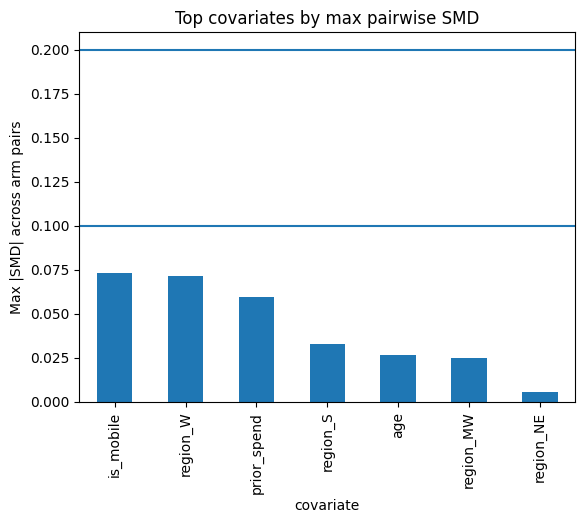

In [6]:
plt.figure()
bal["smd_max_pairwise"].sort_values(ascending=False).head(12).plot(kind="bar")
plt.axhline(0.10)
plt.axhline(0.20)
plt.title("Top covariates by max pairwise SMD")
plt.ylabel("Max |SMD| across arm pairs")
plt.show()


## 4) Estimate effects on a continuous outcome (difference in means)

We simulate a continuous outcome `revenue`.

We create a baseline relationship with covariates, then add true treatment effects:
- variant_a increases mean revenue by +0.30
- variant_b decreases mean revenue by -0.15

Then we estimate:
- variant_a - control
- variant_b - control


In [7]:
true_effects = {"control": 0.00, "variant_a": 0.30, "variant_b": -0.15}

# baseline relationship
base = (
    0.02 * df_assigned["age"]
    + 0.15 * np.log1p(df_assigned["prior_spend"])
    + 0.10 * df_assigned["is_mobile"]
)

noise = rng.normal(0, 1.0, size=n)

df_assigned = df_assigned.copy()
df_assigned["revenue"] = base + df_assigned["arm"].map(true_effects).astype(float) + noise

df_assigned[["arm", "revenue"]].head()


,arm,revenue
0,variant_b,1.401209
1,control,-0.283944
2,variant_b,2.317282
3,variant_a,0.562612
4,control,1.498574


In [8]:
est_means = diff_in_means(
    df_assigned,
    outcome_col="revenue",
    treatment_col="arm",
    reference="control",
    alpha=0.05,
    two_sided=True,
)

est_means


[CausalEstimate(estimand='ATE', contrast='variant_b - control', estimate=-0.14711956762518974, std_error=0.02841896037983553, ci_low=-0.2028197064477381, ci_high=-0.09141942880264137, alpha=0.05, n=6003, method='diff_in_means', meta={'outcome_col': 'revenue', 'treatment_col': 'arm', 'reference': 'control', 'two_sided': True, 'ddof': 1, 'n_arm': 1960, 'n_ref': 4043}),
 CausalEstimate(estimand='ATE', contrast='variant_a - control', estimate=0.2948373018892889, std_error=0.02888661012994823, ci_low=0.2382205863991405, ci_high=0.3514540173794373, alpha=0.05, n=6040, method='diff_in_means', meta={'outcome_col': 'revenue', 'treatment_col': 'arm', 'reference': 'control', 'two_sided': True, 'ddof': 1, 'n_arm': 1997, 'n_ref': 4043})]

In [9]:
def tidy_estimates(estimates):
    rows = []
    for e in estimates:
        rows.append({
            "contrast": e.contrast,
            "estimate": e.estimate,
            "std_error": e.std_error,
            "ci_low": e.ci_low,
            "ci_high": e.ci_high,
            "method": e.method,
        })
    return pd.DataFrame(rows).sort_values("contrast")

tidy_means = tidy_estimates(est_means)
tidy_means


,contrast,estimate,std_error,ci_low,ci_high,method
1,variant_a - control,0.294837,0.028887,0.238221,0.351454,diff_in_means
0,variant_b - control,-0.147120,0.028419,-0.202820,-0.091419,diff_in_means


### Interpreting difference-in-means results

- `estimate` is the estimated change in average revenue relative to control.
- `ci_low` and `ci_high` form an approximate 95% confidence interval (when `alpha=0.05` and `two_sided=True`).
- If the CI does not include 0, this suggests a statistically detectable difference (under the usual assumptions).


## 5) Estimate effects on a binary outcome (difference in proportions)

Now we simulate a conversion outcome `converted`.

We create baseline conversion probability, add treatment effects on the probability scale, and sample conversions.
True effects:
- variant_a increases conversion by +0.02 (absolute)
- variant_b decreases conversion by -0.01 (absolute)
